# 08 - Do the AD-risk nuclei sit in the disease-associated glial states?

The final test: split nuclei on each state marker score at its upper quartile and ask whether
the high group carries more AD polygenic risk (scDRS) than the rest. One-sided Mann-Whitney,
Benjamini-Hochberg across the three states.

Read the result with notebook 05's caveat in mind - the marker sets are small. The reference-label
result in notebook 07 is the stronger version of the same question.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from adpipe import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

cells = pd.read_csv(TABLES / "07_cell_metadata.tsv", sep="\t", index_col=0)
STATES = ["Mic12_score", "Mic13_score", "Ast10_score"]
print(f"{len(cells):,} nuclei | columns: {len(cells.columns)}")

13,214 nuclei | columns: 17


In [2]:
rows = []
for state in STATES:
    thr = cells[state].quantile(0.75)
    high = cells.loc[cells[state] >= thr, "scdrs_norm_score"]
    other = cells.loc[cells[state] < thr, "scdrs_norm_score"]
    _, p = mannwhitneyu(high, other, alternative="greater")
    rho, rho_p = spearmanr(cells[state], cells["scdrs_norm_score"])
    rows.append({"state": state, "threshold_q75": thr,
                 "n_high": len(high), "n_other": len(other),
                 "median_high": high.median(), "median_other": other.median(),
                 "mean_high": high.mean(), "mean_other": other.mean(),
                 "mannwhitney_p": p, "spearman_rho": rho})

enrich = pd.DataFrame(rows)
enrich["fdr"] = multipletests(enrich["mannwhitney_p"], method="fdr_bh")[1]
save_table(enrich, "08_state_enrichment", index=False)
enrich.round(4)

  table -> results/tables/08_state_enrichment.tsv  (3 rows x 11 cols, 1 KB)


,state,threshold_q75,n_high,n_other,median_high,median_other,mean_high,mean_other,mannwhitney_p,spearman_rho,fdr
0,Mic12_score,0.6545,3304,9910,-0.0051,-0.0687,0.0739,-0.0246,0.0007,0.0217,0.0011
1,Mic13_score,0.5410,3304,9910,0.0688,-0.0855,0.1480,-0.0494,0.0000,0.0909,0.0000
2,Ast10_score,0.4534,3304,9910,-0.0686,-0.0424,-0.0326,0.0109,0.9132,-0.0053,0.9132


In [3]:
# The same question asked with the reference labels instead of a marker score
mg = cells["mmc_subclass"] == "Microglia-PVM"
print("Cross-check - are the high-Mic13 nuclei actually microglia?")
for state in STATES:
    thr = cells[state].quantile(0.75)
    high = cells[state] >= thr
    print(f"  {state:12s} high group is {100 * mg[high].mean():5.1f}% Microglia-PVM "
          f"(background: {100 * mg.mean():.1f}%)")

Cross-check - are the high-Mic13 nuclei actually microglia?
  Mic12_score  high group is   9.8% Microglia-PVM (background: 5.1%)
  Mic13_score  high group is  10.1% Microglia-PVM (background: 5.1%)
  Ast10_score  high group is   3.7% Microglia-PVM (background: 5.1%)


  figure -> results/figures/08_state_enrichment.png  (316 KB)


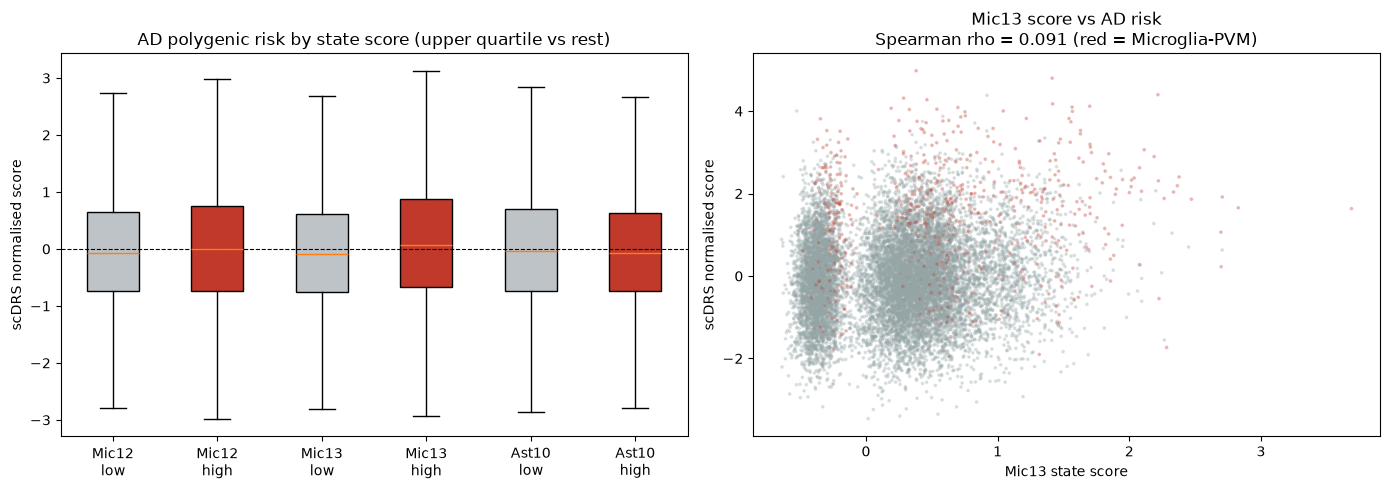

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data, labels = [], []
for state in STATES:
    thr = cells[state].quantile(0.75)
    data += [cells.loc[cells[state] < thr, "scdrs_norm_score"],
             cells.loc[cells[state] >= thr, "scdrs_norm_score"]]
    labels += [f"{state.replace('_score', '')}\nlow", f"{state.replace('_score', '')}\nhigh"]

bp = axes[0].boxplot(data, tick_labels=labels, showfliers=False, patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor("#c0392b" if i % 2 else "#bdc3c7")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set(ylabel="scDRS normalised score",
            title="AD polygenic risk by state score (upper quartile vs rest)")

axes[1].scatter(cells["Mic13_score"], cells["scdrs_norm_score"], s=3, alpha=0.25,
                c=np.where(mg, "#c0392b", "#95a5a6"), rasterized=True)
axes[1].set(xlabel="Mic13 state score", ylabel="scDRS normalised score",
            title=f"Mic13 score vs AD risk\nSpearman rho = "
                  f"{enrich.loc[enrich['state'] == 'Mic13_score', 'spearman_rho'].iloc[0]:.3f} "
                  "(red = Microglia-PVM)")

plt.tight_layout()
save_fig(fig, "08_state_enrichment")
plt.show()

## Everything this pipeline produced

In [5]:
outputs = describe_outputs()
print(f"{len(outputs)} files, {outputs['size_kb'].sum() / 1024:.1f} MB total\n")
outputs

17 files, 6.1 MB total



,file,size_kb
0,results/figures/01_qc_metrics.png,53.6
1,results/figures/02_umap_overview.png,641.7
2,results/figures/03_gwas_qc.png,94.3
3,results/figures/05_marker_scores_umap.png,701.3
4,results/figures/06_scdrs_overview.png,418.2
5,results/figures/07_mapmycells_summary.png,171.2
6,results/figures/08_state_enrichment.png,316.5
7,results/tables/01_qc_summary.tsv,0.1
8,results/tables/02_cluster_composition.tsv,0.7
9,results/tables/03_gwas_qc_summary.tsv,0.2
